## Running the gradient descent loop

This is the algorithm from the paper trace, turned into a loop. We minimize
$f(x) = x^2$ (minimum at $x = 0$), whose derivative is $f'(x) = 2x$.

### The algorithm (five lines)

1. **Start** at some $x$ (here $x = 3$).
2. **Compute the gradient** $f'(x) = 2x$ — the uphill direction.
3. **Step opposite it:** $x_{\text{new}} = x - \alpha \cdot f'(x)$, where $\alpha$
   (the learning rate) sets the step size.
4. **Repeat** steps 2–3 for a set number of iterations.
5. Watch $x$ (and the loss) shrink toward the minimum.

### What the code does

- The single line `x = x - alpha * f_grad(x)` **is** gradient descent — everything
  else is setup and record-keeping.
- We store the loss at every step in `loss_history` so we can plot it.
- The first values the loop produces ($3 \to 2.4 \to 1.92 \to \dots$) match the
  hand-trace exactly — the code just does it faster and for more steps.

### What the plots show

- **Left:** the loss falling each iteration — steep at first, then flattening as
  it nears zero. That flattening is the **self-regulation**: as $x$ approaches the
  minimum, the gradient shrinks, so the steps shrink automatically.
- **Right:** the value of $x$ sliding *down the parabola* from $x = 3$ toward the
  minimum, the dots bunching closer together near the bottom as steps get smaller.

### Learning-rate preview

Each step here multiplies $x$ by $1 - \alpha \cdot 2 = 0.8$ — less than 1, so it
converges. If $\alpha$ were too large the factor could exceed 1 (or go negative),
making the descent overshoot or diverge. That's Day 5's topic — try changing
`alpha` to 0.9 (overshoots) or 1.1 (diverges) after running this.

start:  x = 3.0000,  loss = 9.0000
end:    x = 0.011334,  loss = 0.000128
(true minimum is x = 0, loss = 0)


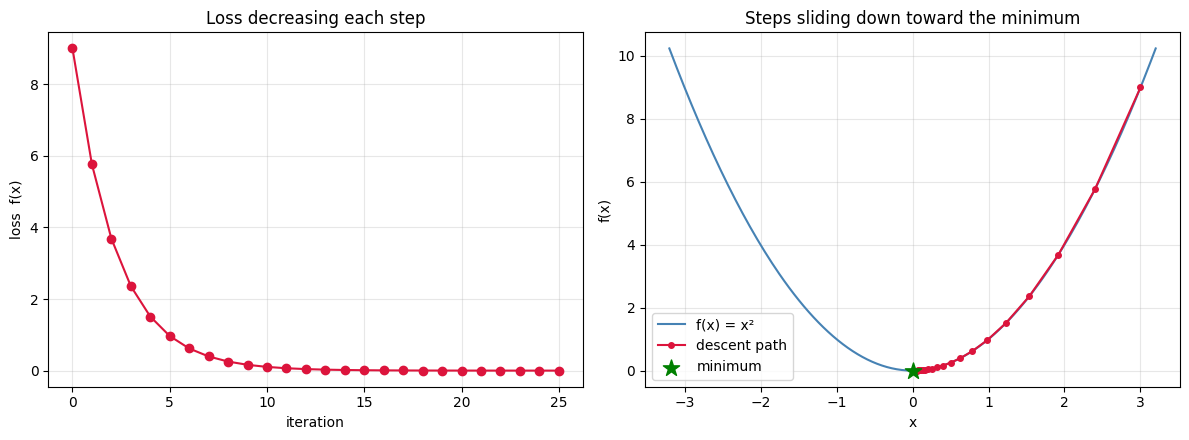

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# minimize f(x) = x^2, whose derivative is f'(x) = 2x
f      = lambda x: x**2
f_grad = lambda x: 2*x

# --- gradient descent ---
x = 3.0            # starting point (same as the hand-trace)
alpha = 0.1        # learning rate
steps = 25

history = [x]                       # record x at each step
loss_history = [f(x)]               # record the loss at each step
for i in range(steps):
    x = x - alpha * f_grad(x)       # THE update: step opposite the gradient
    history.append(x)
    loss_history.append(f(x))

print(f"start:  x = {history[0]:.4f},  loss = {loss_history[0]:.4f}")
print(f"end:    x = {history[-1]:.6f},  loss = {loss_history[-1]:.6f}")
print(f"(true minimum is x = 0, loss = 0)")

# --- plot the loss decreasing ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# left: the loss curve falling over iterations
ax1.plot(loss_history, "o-", color="crimson")
ax1.set_xlabel("iteration"); ax1.set_ylabel("loss  f(x)")
ax1.set_title("Loss decreasing each step")
ax1.grid(True, alpha=0.3)

# right: the path of x sliding down the parabola toward the minimum
xs = np.linspace(-3.2, 3.2, 200)
ax2.plot(xs, f(xs), color="steelblue", label="f(x) = x²")
ax2.plot(history, [f(v) for v in history], "o-", color="crimson",
         markersize=4, label="descent path")
ax2.scatter([0], [0], color="green", marker="*", s=150, zorder=5, label="minimum")
ax2.set_xlabel("x"); ax2.set_ylabel("f(x)")
ax2.set_title("Steps sliding down toward the minimum")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Application : training a real model (weight + bias) with gradient descent

The milestone: instead of minimizing a toy $x^2$, we fit an actual model
$\hat{y} = wx + b$ to data by finding the best $w$ and $b$.

### Loss and gradients (averaged over all data points)

Loss = mean squared error, $L = \frac{1}{n}\sum (wx_i + b - y_i)^2$. Using Day 2's
partials, averaged over the dataset:

$$\frac{\partial L}{\partial w} = \frac{1}{n}\sum 2x_i(\hat{y}_i - y_i), \qquad
\frac{\partial L}{\partial b} = \frac{1}{n}\sum 2(\hat{y}_i - y_i)$$

### The loop
Same as before, but updating **both** parameters each step:
`w = w - alpha * grad_w` and `b = b - alpha * grad_b`.

### What happens
Starting from $w=0, b=0$ (a flat line knowing nothing), the model repeatedly
steps downhill and **discovers** the true relationship ($w \approx 2, b \approx 1$)
from the error alone. The loss falls to the noise floor (not zero, because the
data has noise — this is expected and honest).

### Why it matters
This is machine learning in its most honest form, and essentially the
**linear-regression capstone in miniature**. The capstone adds more inputs (a
weight per feature — vectors/matrices from Block 1) and later logistic regression,
but the engine is exactly this loop.

### New vs the toy example
- two parameters updated together (the gradient is a 2-vector);
- real, noisy data (loss bottoms at the noise floor);
- gradients averaged over the dataset ($\frac{1}{n}\sum$).

learned:  w = 1.814,  b = 1.772
true:     w = 2.000,  b = 1.000  (approx, before noise)
final loss (MSE) = 1.0506


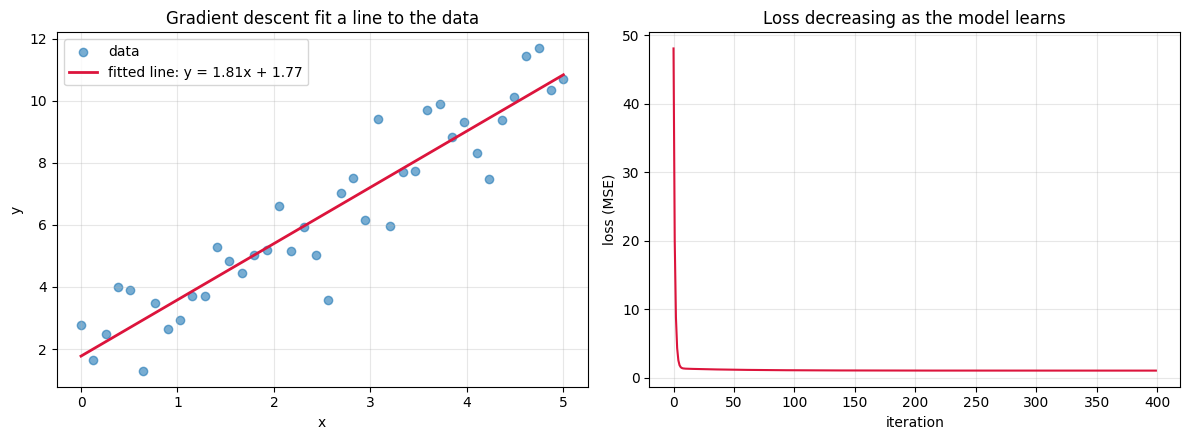

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- fake data that roughly follows y = 2x + 1, plus noise ---
np.random.seed(0)
x_data = np.linspace(0, 5, 40)
y_data = 2.0 * x_data + 1.0 + np.random.normal(0, 1.0, size=x_data.shape)
# true relationship: slope ~2, bias ~1 -- gradient descent should discover this

# --- initialise the two parameters ---
w, b = 0.0, 0.0          # start with a flat line at zero
alpha = 0.02
steps = 400
n = len(x_data)

loss_history = []
for i in range(steps):
    y_pred = w * x_data + b               # predictions for all points
    error  = y_pred - y_data             # (y_hat - y) for each point

    # gradients (averaged over all data points)
    grad_w = (2/n) * np.sum(error * x_data)
    grad_b = (2/n) * np.sum(error)

    # THE update: step BOTH parameters opposite their gradients
    w = w - alpha * grad_w
    b = b - alpha * grad_b

    loss_history.append(np.mean(error**2))   # MSE at this step

print(f"learned:  w = {w:.3f},  b = {b:.3f}")
print(f"true:     w = 2.000,  b = 1.000  (approx, before noise)")
print(f"final loss (MSE) = {loss_history[-1]:.4f}")

# --- plots: the fitted line, and the loss curve ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.scatter(x_data, y_data, alpha=0.6, label="data")
ax1.plot(x_data, w*x_data + b, color="crimson", lw=2,
         label=f"fitted line: y = {w:.2f}x + {b:.2f}")
ax1.set_xlabel("x"); ax1.set_ylabel("y")
ax1.set_title("Gradient descent fit a line to the data")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(loss_history, color="crimson")
ax2.set_xlabel("iteration"); ax2.set_ylabel("loss (MSE)")
ax2.set_title("Loss decreasing as the model learns")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Self-check — Day 4 (Gradient Descent)

Answer each out loud before opening the answers.

**Q1.** State the gradient descent algorithm in your own words (the five steps).

**Q2.** Write the update rule, and explain what the minus sign and $\alpha$ each do.

**Q3.** For $f(x) = x^2$ (so $f'(x) = 2x$), starting at $x = 3$ with $\alpha = 0.1$,
compute the first two updated values of $x$.

**Q4.** Why do the steps get *smaller* as descent approaches the minimum, without
anyone telling it to slow down?

**Q5.** How does gradient descent know when to stop?

**Q6.** In the two-parameter fit ($\hat{y} = wx + b$), why does the final loss
settle near the noise level instead of reaching zero?

**Q7.** For $f(x) = x^2$, one step multiplies $x$ by $1 - 2\alpha$. What does this
tell you about a learning rate of $\alpha = 1$?

---

<details>
<summary>Answers</summary>

**A1.** (1) Start at some parameter values. (2) Compute the gradient there.
(3) Step opposite the gradient: $\theta \leftarrow \theta - \alpha\nabla L$.
(4) Repeat. (5) Stop when the gradient is ~0 (at the minimum) or after a set
number of iterations.

**A2.** $\theta_{\text{new}} = \theta_{\text{old}} - \alpha\nabla L$. The **minus**
makes you step in the *downhill* direction (opposite the uphill gradient). $\alpha$
(learning rate) controls **step size** — how far you move each iteration.

**A3.** Start $x=3$: grad $=6$, $x = 3 - 0.1(6) = 2.4$. Next: grad $=4.8$,
$x = 2.4 - 0.1(4.8) = 1.92$.

**A4.** Because the step size is proportional to the gradient's magnitude, and the
gradient shrinks as you near the minimum (the surface flattens). Smaller gradient
→ smaller step, automatically. It's self-regulating.

**A5.** When the gradient is (near) zero — no downhill direction left, so updates
stop changing the parameters — or after a preset number of iterations.

**A6.** The data has noise, so no line can pass through every point. The lowest
possible average error is the noise floor; gradient descent reaches that, not zero.

**A7.** The factor $1 - 2(1) = -1$ means each step multiplies $x$ by $-1$ — the
value flips sign and never shrinks, so it oscillates forever without converging.
The learning rate is too large. (This is Day 5's topic.)

</details>